# validation of Neural Score Estimator (NSE) population likelihood

In [1]:
import numpy as np
from tqdm import tqdm
from functools import partial

In [2]:
import torch
import tarp
from mira_score import mira

In [3]:
from px2cosmo import fm as FM
from px2cosmo import util as UT
from px2cosmo.nse import NSE, gaussian_prior_score

In [4]:
import corner as DFM
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

# construct test data

In [5]:
bounds = np.array(UT._prior_range_default())[:-1]

In [ ]:
# construct test data — reuse saved files if available
Nmocks = 1000

_test_omegas = np.array([
    np.random.uniform(bounds[0][0], bounds[0][1], size=Nmocks),
    np.random.uniform(bounds[1][0], bounds[1][1], size=Nmocks),
    np.random.uniform(bounds[2][0], bounds[2][1], size=Nmocks),
    np.random.uniform(bounds[3][0], bounds[3][1], size=Nmocks)
]).T

i_comp = []
test_Xsig_z14, test_Xsig_z11, test_Xsig_z9 = [], [], []
for ii in tqdm(range(Nmocks)):
    mock = FM.sampleLF(_test_omegas[ii], phi_amp=6e-3)
    results = []
    for name in ('z14', 'z11', 'z9'):
        obs = FM.apply_selection_noise(mock, name)
        if obs.shape[0] == 0: continue
        i = np.random.randint(obs.shape[0])
        results.append(obs[i])
    if len(results) < 3: continue
    i_comp.append(ii)
    test_Xsig_z14.append(results[0])
    test_Xsig_z11.append(results[1])
    test_Xsig_z9.append(results[2])

test_omegas   = _test_omegas[np.array(i_comp)]
test_Xsig_z14 = np.array(test_Xsig_z14)
test_Xsig_z11 = np.array(test_Xsig_z11)
test_Xsig_z9  = np.array(test_Xsig_z9)

np.save('/Users/ch54662/data/px2cosmo/mock/test_population_omega.npy', test_omegas)
np.save('/Users/ch54662/data/px2cosmo/mock/test_population_z14_Xsig.npy', test_Xsig_z14)
np.save('/Users/ch54662/data/px2cosmo/mock/test_population_z11_Xsig.npy', test_Xsig_z11)
np.save('/Users/ch54662/data/px2cosmo/mock/test_population_z9_Xsig.npy', test_Xsig_z9)

In [6]:
test_omegas   = np.load('/Users/ch54662/data/px2cosmo/mock/test_population_omega.npy')
test_Xsig_z14 = np.load('/Users/ch54662/data/px2cosmo/mock/test_population_z14_Xsig.npy')
test_Xsig_z11 = np.load('/Users/ch54662/data/px2cosmo/mock/test_population_z11_Xsig.npy')
test_Xsig_z9  = np.load('/Users/ch54662/data/px2cosmo/mock/test_population_z9_Xsig.npy')

# validate NSE (TARP + MIRA)

In [32]:
# ── fill in paths to trained NSE checkpoints ──────────────────────────────────
nse_models = {
    'z14': None,
    #'z11': '/Users/ch54662/data/px2cosmo/mock/ndes/q_omega_Xsig_z11_fnse/q_omega_Xsig_z11_fnse.19.pt',
    'z11': '/Users/ch54662/data/px2cosmo/mock/ndes/q_omega_Xsig_z11_nse/q_omega_Xsig_z11_nse.44.pt',
    'z9':  None,
}

In [8]:
def load_nse(model_path):
    '''Load NSE from dm_pop.py checkpoint.'''
    ckpt = torch.load(model_path, weights_only=False, map_location='cpu')
    nse  = NSE(**ckpt['arch'])
    nse.load_state_dict(ckpt['state_dict'])
    nse.eval()
    return nse, ckpt


def validate_NSE(model_path, test_Xsig, n_samples=500, steps=300):
    '''TARP + MIRA calibration check for a trained NSE.

    For each test observation (z, Muv, sig_z, sig_Muv), runs DDIM to obtain
    posterior samples over omega, then checks coverage against the true omega.

    Args:
        test_Xsig: (n_test, 4) — single galaxy observations for each test omega.
    Returns:
        ecp, alpha: TARP expected coverage and credibility levels.
        mean_score, std_score: MIRA score (mean ± std over Monte Carlo runs).
    '''
    nse, ckpt = load_nse(model_path)
    _bounds   = ckpt['bounds']
    x_mean    = torch.tensor(ckpt['x_mean'], dtype=torch.float32)
    x_std     = torch.tensor(ckpt['x_std'],  dtype=torch.float32)

    # preprocess observations
    x_obs   = torch.tensor(test_Xsig.astype(np.float32))          # (n_test, 4)
    x_obs_w = (x_obs - x_mean) / x_std                             # whitened

    # batched DDIM: (n_test, n_samples, 4) in CDF-transformed space
    with torch.no_grad():
        samples_w = nse.ddim_batched(n_samples, x_obs_w, steps=steps).numpy()

    # back-transform to omega space
    samples = np.zeros_like(samples_w)
    for i in range(4):
        samples[:, :, i] = UT.cdf_transform(samples_w[:, :, i], _bounds[i])

    # TARP: (n_samples, n_test, 4) and (n_test, 4)
    ecp, alpha = tarp.get_tarp_coverage(
        samples.transpose(1, 0, 2), test_omegas, norm='max'
    )

    # MIRA: (n_test, 4) observations and (1, n_test, n_samples, 4) samples
    test_X_t   = torch.tensor(test_omegas.astype(np.float32))
    samples_t  = torch.tensor(samples)
    mean_score, std_score = mira(test_X_t, samples_t[None], num_runs=100)

    return ecp, alpha, mean_score, std_score

# validate $z=14$ NSE

In [ ]:
ecp_z14, alpha_z14, mean_score_z14, std_score_z14 = validate_NSE(
    nse_models['z14'], test_Xsig_z14
)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot([0, 1], [0, 1], ls='--', color='k')
ax.plot(alpha_z14, ecp_z14, label=r'NSE $z{=}14$')
ax.legend(fontsize=20, handletextpad=0.2)
ax.set_ylabel('Expected Coverage', fontsize=25)
ax.set_xlabel('Credibility Level', fontsize=25)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.show()

# validate $z=11$ NSE

In [9]:
ecp_z11, alpha_z11, mean_score_z11, std_score_z11 = validate_NSE(
    nse_models['z11'], test_Xsig_z11
)

Mira MC runs: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 142.84it/s]


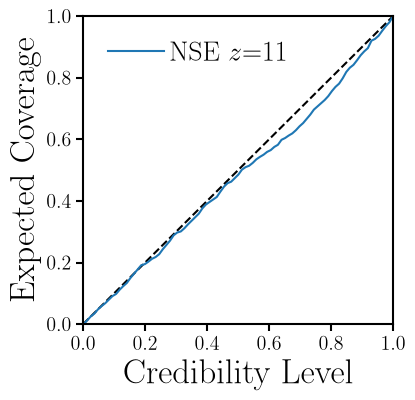

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot([0, 1], [0, 1], ls='--', color='k')
ax.plot(alpha_z11, ecp_z11, label=r'NSE $z{=}11$')
ax.legend(fontsize=20, handletextpad=0.2)
ax.set_ylabel('Expected Coverage', fontsize=25)
ax.set_xlabel('Credibility Level', fontsize=25)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.show()

# validate $z=9$ NSE

In [ ]:
ecp_z9, alpha_z9, mean_score_z9, std_score_z9 = validate_NSE(
    nse_models['z9'], test_Xsig_z9
)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot([0, 1], [0, 1], ls='--', color='k')
ax.plot(alpha_z9, ecp_z9, label=r'NSE $z{=}9$')
ax.legend(fontsize=20, handletextpad=0.2)
ax.set_ylabel('Expected Coverage', fontsize=25)
ax.set_xlabel('Credibility Level', fontsize=25)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.show()

# validation plots

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot([0, 1], [0, 1], ls='--', color='k')
ax.plot(alpha_z14, ecp_z14, label=r'NSE $z{=}14$')
ax.plot(alpha_z11, ecp_z11, label=r'NSE $z{=}11$')
ax.plot(alpha_z9,  ecp_z9,  label=r'NSE $z{=}9$')
ax.legend(fontsize=15, handletextpad=0.2)
ax.set_ylabel('Expected Coverage', fontsize=25)
ax.set_xlabel('Credibility Level', fontsize=25)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
fig.savefig('nse_tarp.pdf', bbox_inches='tight')
plt.show()

In [ ]:
L = test_omegas.shape[0]
fig = plt.figure(figsize=(4, 2))
sub = fig.add_subplot(111)
sub.fill_between([0., 1.],
    [2/3 + np.sqrt(1/18/L)] * 2,
    [2/3 - np.sqrt(1/18/L)] * 2,
    edgecolor='none', color='k', alpha=0.2)
sub.plot([0., 1.], [2/3, 2/3], c='k', ls='--')
sub.plot([0., 1.], [0.5, 0.5], c='k', ls=':')
sub.errorbar([0.25], [mean_score_z14.item()], yerr=[std_score_z14.item()], c='C2', fmt='o', markersize=5)
sub.errorbar([0.50], [mean_score_z11.item()], yerr=[std_score_z11.item()], c='C1', fmt='o', markersize=5)
sub.errorbar([0.75], [mean_score_z9.item()],  yerr=[std_score_z9.item()],  c='C0', fmt='o', markersize=5)
sub.text(0.5, 0.685, 'underconfident', ha='center', va='center', fontsize=15)
sub.text(0.5, 0.645, 'overconfident',  ha='center', va='center', fontsize=15)
sub.text(0.05, 0.95, r'NSE', fontsize=20, transform=sub.transAxes, ha='left', va='top')
sub.set_xlim(0.1, 0.9)
sub.set_xticks([0.25, 0.5, 0.75])
sub.set_xticklabels([r'$z{=}14$', r'$z{=}11$', r'$z{=}9$'])
sub.set_ylim(0.63, 0.7)
sub.set_ylabel('MIRA score', fontsize=20)
fig.savefig('nse_mira.pdf', bbox_inches='tight')
plt.show()

# tall-data posterior: Geffner vs GAUSS vs JAC

In [11]:
# load observation data (same files as likelihood_population.ipynb)
omega_true  = np.load('/Users/ch54662/data/px2cosmo/mock/omega_true.npy')
X_obs_z14   = np.load('/Users/ch54662/data/px2cosmo/mock/X_obs_z14.npy')
X_obs_z11   = np.load('/Users/ch54662/data/px2cosmo/mock/X_obs_z11.npy')
X_obs_z9    = np.load('/Users/ch54662/data/px2cosmo/mock/X_obs_z9.npy')

In [12]:
def log_prior(omega):
    alpha, beta, gamma, Muv_s = omega
    if (bounds[0][0] < alpha < bounds[0][1] and
        bounds[1][0] < beta  < bounds[1][1] and
        bounds[2][0] < gamma < bounds[2][1] and
        bounds[3][0] < Muv_s < bounds[3][1]):
        return 0.
    return -np.inf

In [16]:
def sample_posterior(model_path, X_obs, n_samples=1000, steps=500,
                     modes=('geffner', 'gauss'),
                     gauss_cov_samples=500, gauss_cov_steps=100):
    '''Sample the tall-data posterior using Geffner, GAUSS, and JAC scores.

    Args:
        X_obs: (N_obs, 4) — all galaxy observations for one z-bin.
        n_samples: posterior draws per mode.
        modes: which factorized scores to run.
        gauss_cov_samples: DDIM samples used to estimate covariances for GAUSS.
    Returns:
        dict mapping mode name -> omega samples (n_samples, 4) in original space.
    '''
    nse, ckpt = load_nse(model_path)
    _bounds   = ckpt['bounds']
    x_mean    = torch.tensor(ckpt['x_mean'], dtype=torch.float32)
    x_std     = torch.tensor(ckpt['x_std'],  dtype=torch.float32)

    # preprocess all observations
    x_obs   = torch.tensor(X_obs.astype(np.float32))      # (N_obs, 4)
    x_obs_w = (x_obs - x_mean) / x_std

    prior_fn = partial(gaussian_prior_score, nse=nse)

    # pre-compute covariances for GAUSS (done once)
    dist_cov_est = None
    if 'gauss' in modes:
        print('estimating posterior covariances for GAUSS...')
        dist_cov_est = nse.estimate_posterior_covs(
            x_obs_w, n_samples=gauss_cov_samples, steps=gauss_cov_steps
        )

    results = {}
    for mode in modes:
        print(f'sampling with mode={mode}...')
        kwargs = dict(steps=steps, prior_score_fn=prior_fn, mode=mode)
        if mode == 'gauss':
            kwargs['dist_cov_est'] = dist_cov_est
        samples_w = nse.ddim((n_samples,), x=x_obs_w, **kwargs).numpy()

        # back-transform to omega space
        samples = np.zeros_like(samples_w)
        for i in range(4):
            samples[:, i] = UT.cdf_transform(samples_w[:, i], _bounds[i])
        results[mode] = samples

    return results

In [ ]:
mode_labels = {'geffner': 'Geffner', 'gauss': 'GAUSS', 'jac': 'JAC'}
mode_colors = {'geffner': 'C0', 'gauss': 'C1', 'jac': 'C2'}

## $z=14$

In [ ]:
post_z14 = sample_posterior(nse_models['z14'], X_obs_z14)

In [ ]:
fig = None
for i, (mode, samples) in enumerate(post_z14.items()):
    fig = DFM.corner(
        samples, color=mode_colors[mode],
        plot_density=False, plot_datapoints=False,
        range=bounds.tolist(), hist_kwargs={'density': True},
        labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$'],
        label_kwargs={'fontsize': 20}, fig=fig)

DFM.overplot_points(fig, [omega_true[:-1]], color='red')
DFM.overplot_lines(fig,   omega_true[:-1],  color='red')

# legend
handles = [mpl.lines.Line2D([], [], color=mode_colors[m], label=mode_labels[m])
           for m in post_z14]
fig.axes[0].legend(handles=handles, fontsize=12, loc='upper right',
                   bbox_to_anchor=(4, 4), frameon=False)
fig.suptitle(r'$z=14$ posterior', fontsize=18)
fig.savefig('nse_posterior_z14.pdf', bbox_inches='tight')
plt.show()

## $z=11$

In [36]:
post_z11 = sample_posterior(nse_models['z11'], X_obs_z11[::10], modes=('geffner', 'gauss'))

estimating posterior covariances for GAUSS...
sampling with mode=geffner...
sampling with mode=gauss...


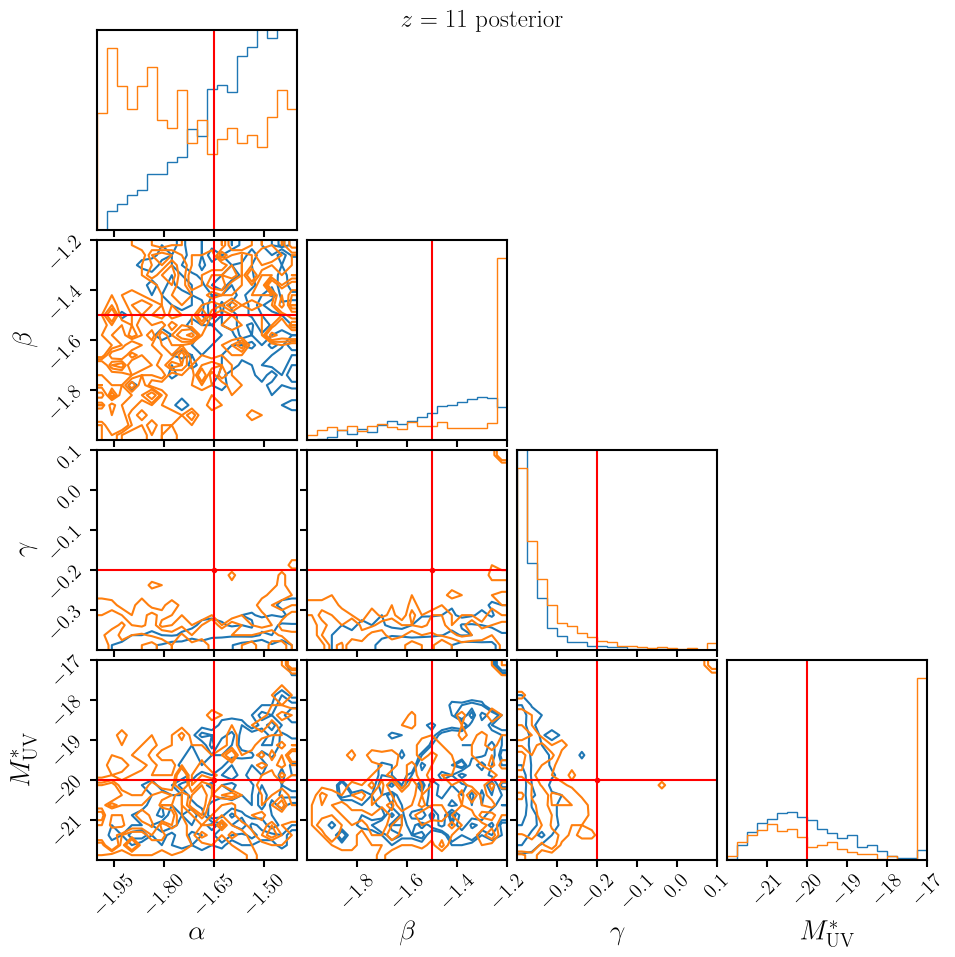

In [34]:
fig = None
for mode, samples in post_z11.items():
    fig = DFM.corner(
        samples, color=mode_colors[mode],
        plot_density=False, plot_datapoints=False,
        range=bounds.tolist(), hist_kwargs={'density': True},
        labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$'],
        label_kwargs={'fontsize': 20}, fig=fig)

DFM.overplot_points(fig, [omega_true[:-1]], color='red')
DFM.overplot_lines(fig,   omega_true[:-1],  color='red')
fig.suptitle(r'$z=11$ posterior', fontsize=18)
plt.show()

## $z=9$

In [ ]:
post_z9 = sample_posterior(nse_models['z9'], X_obs_z9)

In [ ]:
fig = None
for mode, samples in post_z9.items():
    fig = DFM.corner(
        samples, color=mode_colors[mode],
        plot_density=False, plot_datapoints=False,
        range=bounds.tolist(), hist_kwargs={'density': True},
        labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$'],
        label_kwargs={'fontsize': 20}, fig=fig)

DFM.overplot_points(fig, [omega_true[:-1]], color='red')
DFM.overplot_lines(fig,   omega_true[:-1],  color='red')
fig.suptitle(r'$z=9$ posterior', fontsize=18)
fig.savefig('nse_posterior_z9.pdf', bbox_inches='tight')
plt.show()